# 04 · Train EfficientNet-B0 (+ optional B2)

**Checklist:**
- [ ] Notebook 03 complete — ResNet-50 checkpoint saved to Drive
- [ ] Runtime → **A100 GPU**

In [1]:
# ── Cell 1: Setup ─────────────────────────────────────────────────────
import os, sys

GITHUB_USER = 'musarashid49'
REPO_NAME   = 'Image-Classification-with-CNN'
REPO_DIR    = f'/content/{REPO_NAME}'

if not os.path.isdir(REPO_DIR):
    !git clone https://github.com/{GITHUB_USER}/{REPO_NAME}.git {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)

from google.colab import drive
drive.mount('/content/drive')

import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else '⚠ NOT FOUND')

Cloning into '/content/Image-Classification-with-CNN'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 60 (delta 20), reused 43 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 907.61 KiB | 32.41 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Mounted at /content/drive
GPU: NVIDIA A100-SXM4-40GB


In [3]:
# ── Cell 2: Paths ─────────────────────────────────────────────────────
LOCAL_DATA_DIR   = '/content/data'
DRIVE_SPLIT_PATH = '/content/drive/MyDrive/dataset_resplit'  # ← changed
DRIVE_RESULTS    = '/content/drive/MyDrive/pk_politicians_results'

In [4]:
from src.utils import copy_dataset_from_drive, set_seed
from src.dataset import get_dataloaders

set_seed(42)
copy_dataset_from_drive(DRIVE_SPLIT_PATH, LOCAL_DATA_DIR)

loaders = get_dataloaders(
    os.path.join(LOCAL_DATA_DIR, 'train'),
    os.path.join(LOCAL_DATA_DIR, 'val'),
    os.path.join(LOCAL_DATA_DIR, 'test'),
)

  Global seed set to 42
  Copying dataset from Drive …
  Done in 996.0s  →  /content/data

── DataLoader Summary ──────────────────────────────────────
  train     1064 images  |    33 batches  |  classes: 16
  val        205 images  |     7 batches  |  classes: 16
  test       159 images  |     5 batches  |  classes: 16

  Class-to-index mapping:
    [ 0]  ahmed_sharif_chaudhry
    [ 1]  altaf_hussain
    [ 2]  asfandyar_wali
    [ 3]  asif_ali_zardari
    [ 4]  bilawal_bhutto
    [ 5]  chaudhry_nisar
    [ 6]  fazlur_rehman
    [ 7]  imran_khan
    [ 8]  maryam_nawaz
    [ 9]  nawaz_sharif
    [10]  pervez_khattak
    [11]  pervez_musharraf
    [12]  rana_sanaullah
    [13]  shah_mehmood_qureshi
    [14]  shehbaz_sharif
    [15]  sirajul_haq


In [5]:
# ═══════════════════════════════════════════════
# EfficientNet-B0
# ═══════════════════════════════════════════════
from src.models import build_model
from src.train  import Trainer

model_b0 = build_model('efficientnet_b0', num_classes=16, dropout=0.4)

trainer_b0 = Trainer(
    model      = model_b0,
    loaders    = loaders,
    model_name = 'efficientnet_b0',
    config_overrides = {'num_epochs': 30, 'learning_rate': 1e-4}
)
history_b0 = trainer_b0.run()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 234MB/s]

  [efficientnet_b0]  trainable params: 4,028,044 / 4,028,044


Training on: cuda


  train:   0%|          | 0/33 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  train:   3%|▎         | 1/33 [00:02<01:29,  2.81s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Epoch [ 28/30]  train_loss=0.0216  train_acc=0.9981  val_loss=0.3256  val_acc=0.9073  (5.5s)


  train:  27%|██▋       | 9/33 [00:01<00:03,  6.60it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [ 29/30]  train_loss=0.0214  train_acc=0.9972  val_loss=0.3107  val_acc=0.9073  (5.6s)


  train:   6%|▌         | 2/33 [00:00<00:09,  3.11it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  train:  52%|█████▏    | 17/33 [00:02<00:01,  8.28it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
                                                    

Epoch [ 30/30]  train_loss=0.0260  train_acc=0.9972  val_loss=0.3101  val_acc=0.9171  (6.0s)
  Early stopping triggered at epoch 30.

Training complete. Best val_acc = 0.9220
History saved → results/metrics/efficientnet_b0_history.json


  Training curves saved → results/plots/efficientnet_b0_training_curves.png

── Classification Report [efficientnet_b0] ──────────────────
                       precision    recall  f1-score   support

ahmed_sharif_chaudhry       1.00      1.00      1.00         8
        altaf_hussain       1.00      1.00      1.00        11
       asfandyar_wali       1.00      1.00      1.00        11
     asif_ali_zardari       0.86      0.75      0.80         8
       bilawal_bhutto       1.00      0.88      0.93         8
       chaudhry_nisar       0.64      0.64      0.64        11
        fazlur_rehman       0.86      0.92      0.89        13
           imran_khan       0.77      1.00      0.87        10
         maryam_nawaz       0.81      0.93      0.87        14
         nawaz_sharif       1.00      1.00      1.00         8
       pervez_khattak       0.88      0.88      0.88         8
     pervez_musharraf       0.90      0.75      0.82        12
       rana_sanaullah       0.89      0.8

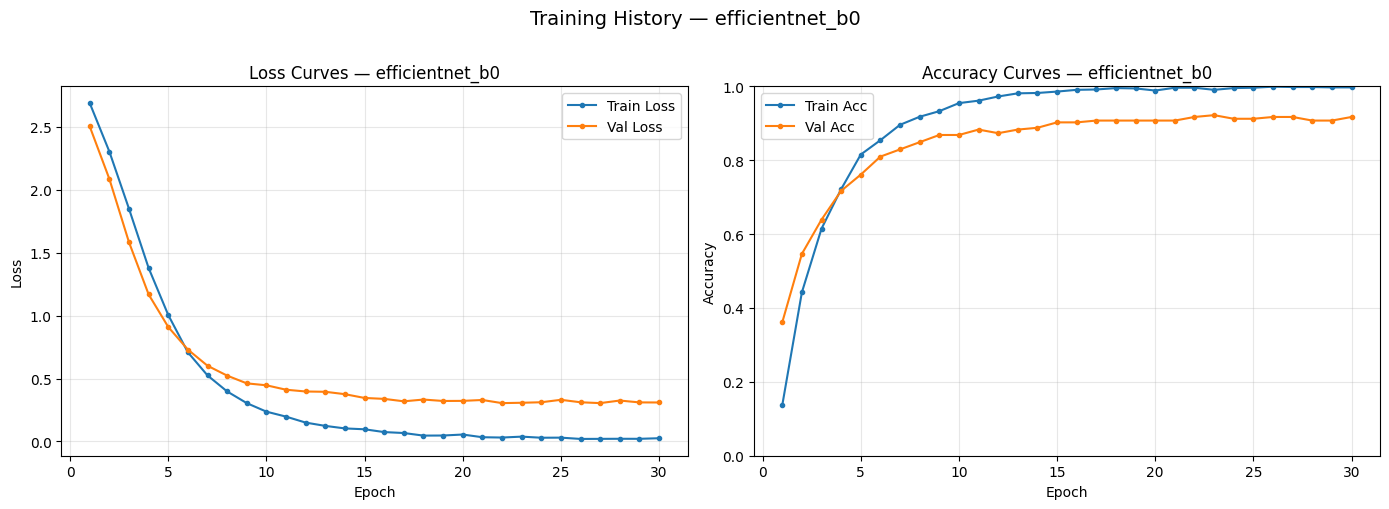

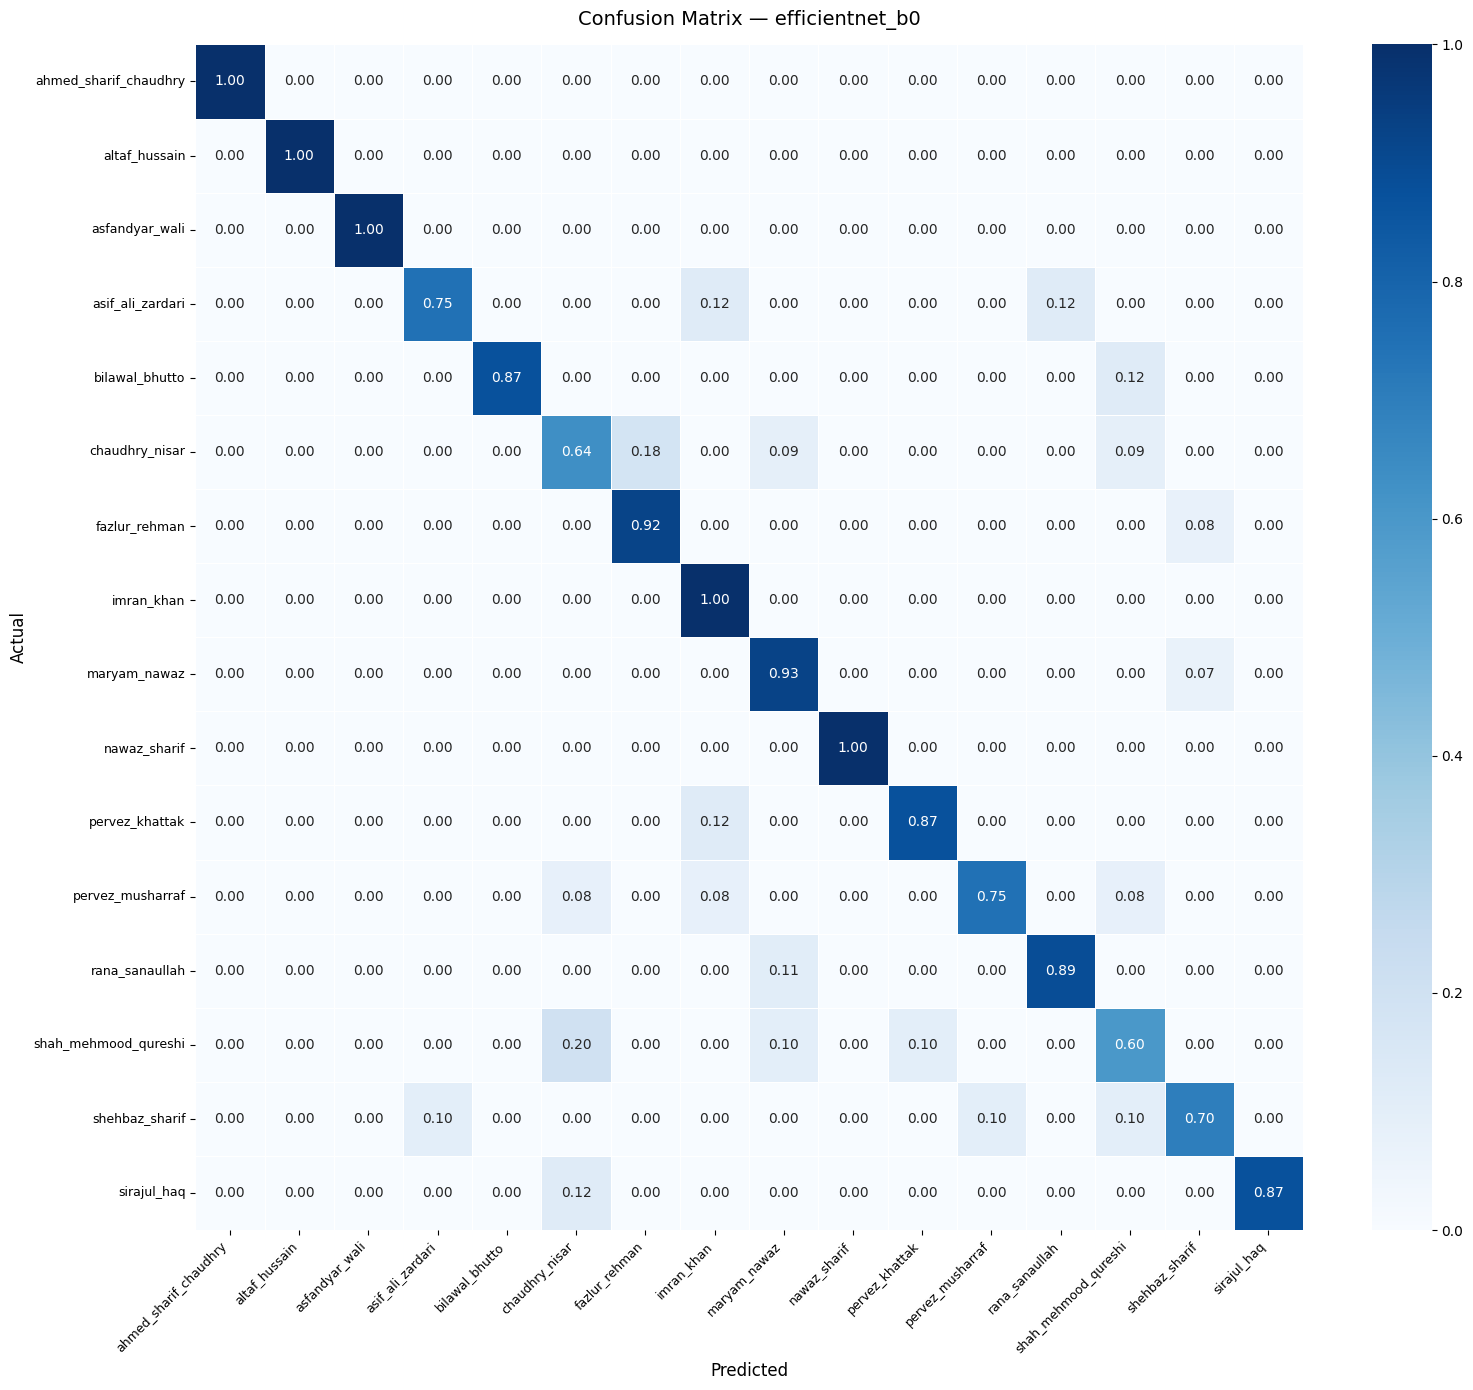

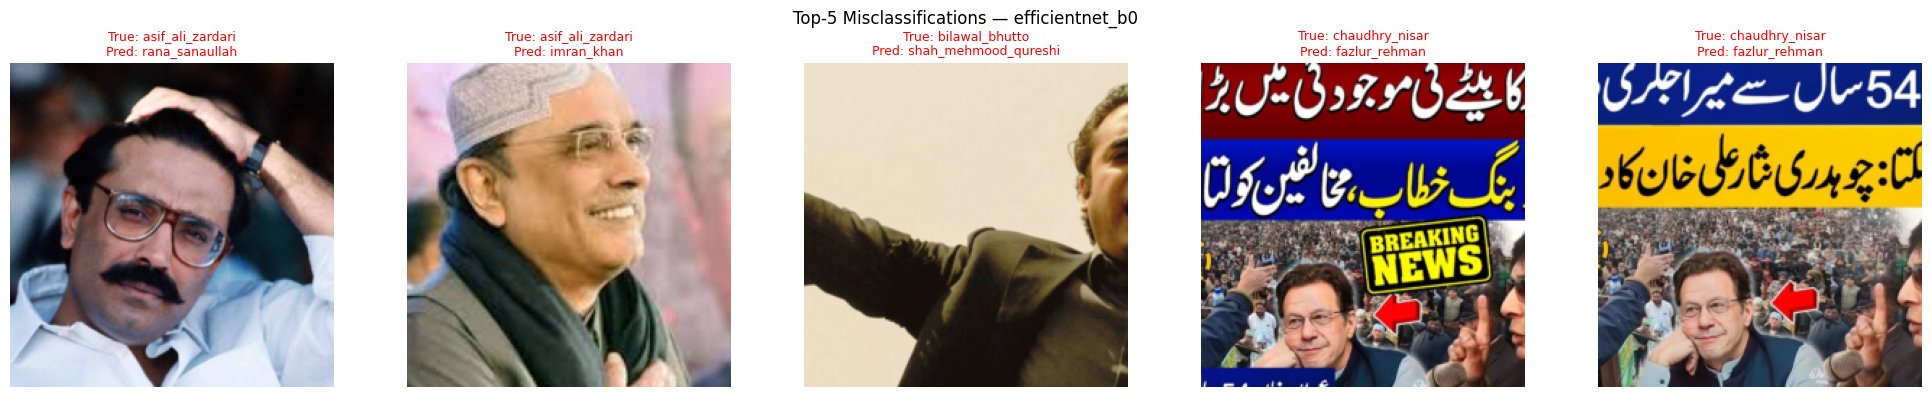

In [6]:
from src.evaluate import evaluate_model, plot_training_curves, plot_confusion_matrix, plot_misclassified

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plot_training_curves(history_b0, 'efficientnet_b0').show()

res_b0 = evaluate_model(model_b0, loaders['test'], device, model_name='efficientnet_b0')
plot_confusion_matrix(res_b0['y_true'], res_b0['y_pred'], model_name='efficientnet_b0').show()
fig = plot_misclassified(res_b0['images'], res_b0['y_true'], res_b0['y_pred'], model_name='efficientnet_b0')
if fig: fig.show()


── DataLoader Summary ──────────────────────────────────────
  train     1064 images  |    33 batches  |  classes: 16
  val        205 images  |     7 batches  |  classes: 16
  test       159 images  |     5 batches  |  classes: 16

  Class-to-index mapping:
    [ 0]  ahmed_sharif_chaudhry
    [ 1]  altaf_hussain
    [ 2]  asfandyar_wali
    [ 3]  asif_ali_zardari
    [ 4]  bilawal_bhutto
    [ 5]  chaudhry_nisar
    [ 6]  fazlur_rehman
    [ 7]  imran_khan
    [ 8]  maryam_nawaz
    [ 9]  nawaz_sharif
    [10]  pervez_khattak
    [11]  pervez_musharraf
    [12]  rana_sanaullah
    [13]  shah_mehmood_qureshi
    [14]  shehbaz_sharif
    [15]  sirajul_haq
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 241MB/s]


  [efficientnet_b2]  trainable params: 7,723,538 / 7,723,538
Training on: cuda


  train:   0%|          | 0/33 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  train:  15%|█▌        | 5/33 [00:01<00:06,  4.47it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  train:  33%|███▎      | 11/33 [00:02<00:02,  7.84it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [  1/30]  train_loss=2.6214  train_acc=0.2083  val_loss=2.3765  val_acc=0.4829  (6.5s)
  ✓ Checkpoint saved  (val_acc=0.4829)


...

  train:   0%|          | 0/33 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  train:  94%|█████████▍| 31/33 [00:05<00:00,  8.18it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [ 27/30]  train_loss=0.0133  train_acc=1.0000  val_loss=0.2635  val_acc=0.9073  (6.6s)


  train:  45%|████▌     | 15/33 [00:02<00:02,  7.76it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  train:  67%|██████▋   | 22/33 [00:03<00:01,  6.04it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  train:  76%|███████▌  | 25/33 [00:04<00:01,  6.58it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
                                                    

Epoch [ 28/30]  train_loss=0.0163  train_acc=0.9991  val_loss=0.2366  val_acc=0.9171  (6.2s)
  Early stopping triggered at epoch 28.

Training complete. Best val_acc = 0.9317
History saved → results/metrics/efficientnet_b2_history.json



── Classification Report [efficientnet_b2] ──────────────────
                       precision    recall  f1-score   support

ahmed_sharif_chaudhry       1.00      1.00      1.00         8
        altaf_hussain       0.92      1.00      0.96        11
       asfandyar_wali       1.00      1.00      1.00        11
     asif_ali_zardari       1.00      0.75      0.86         8
       bilawal_bhutto       1.00      1.00      1.00         8
       chaudhry_nisar       0.64      0.64      0.64        11
        fazlur_rehman       1.00      0.92      0.96        13
           imran_khan       0.77      1.00      0.87        10
         maryam_nawaz       0.65      0.93      0.76        14
         nawaz_sharif       0.89      1.00      0.94         8
       pervez_khattak       1.00      0.88      0.93         8
     pervez_musharraf       1.00      0.83      0.91        12
       rana_sanaullah       1.00      1.00      1.00         9
 shah_mehmood_qureshi       1.00      0.70      0.82  

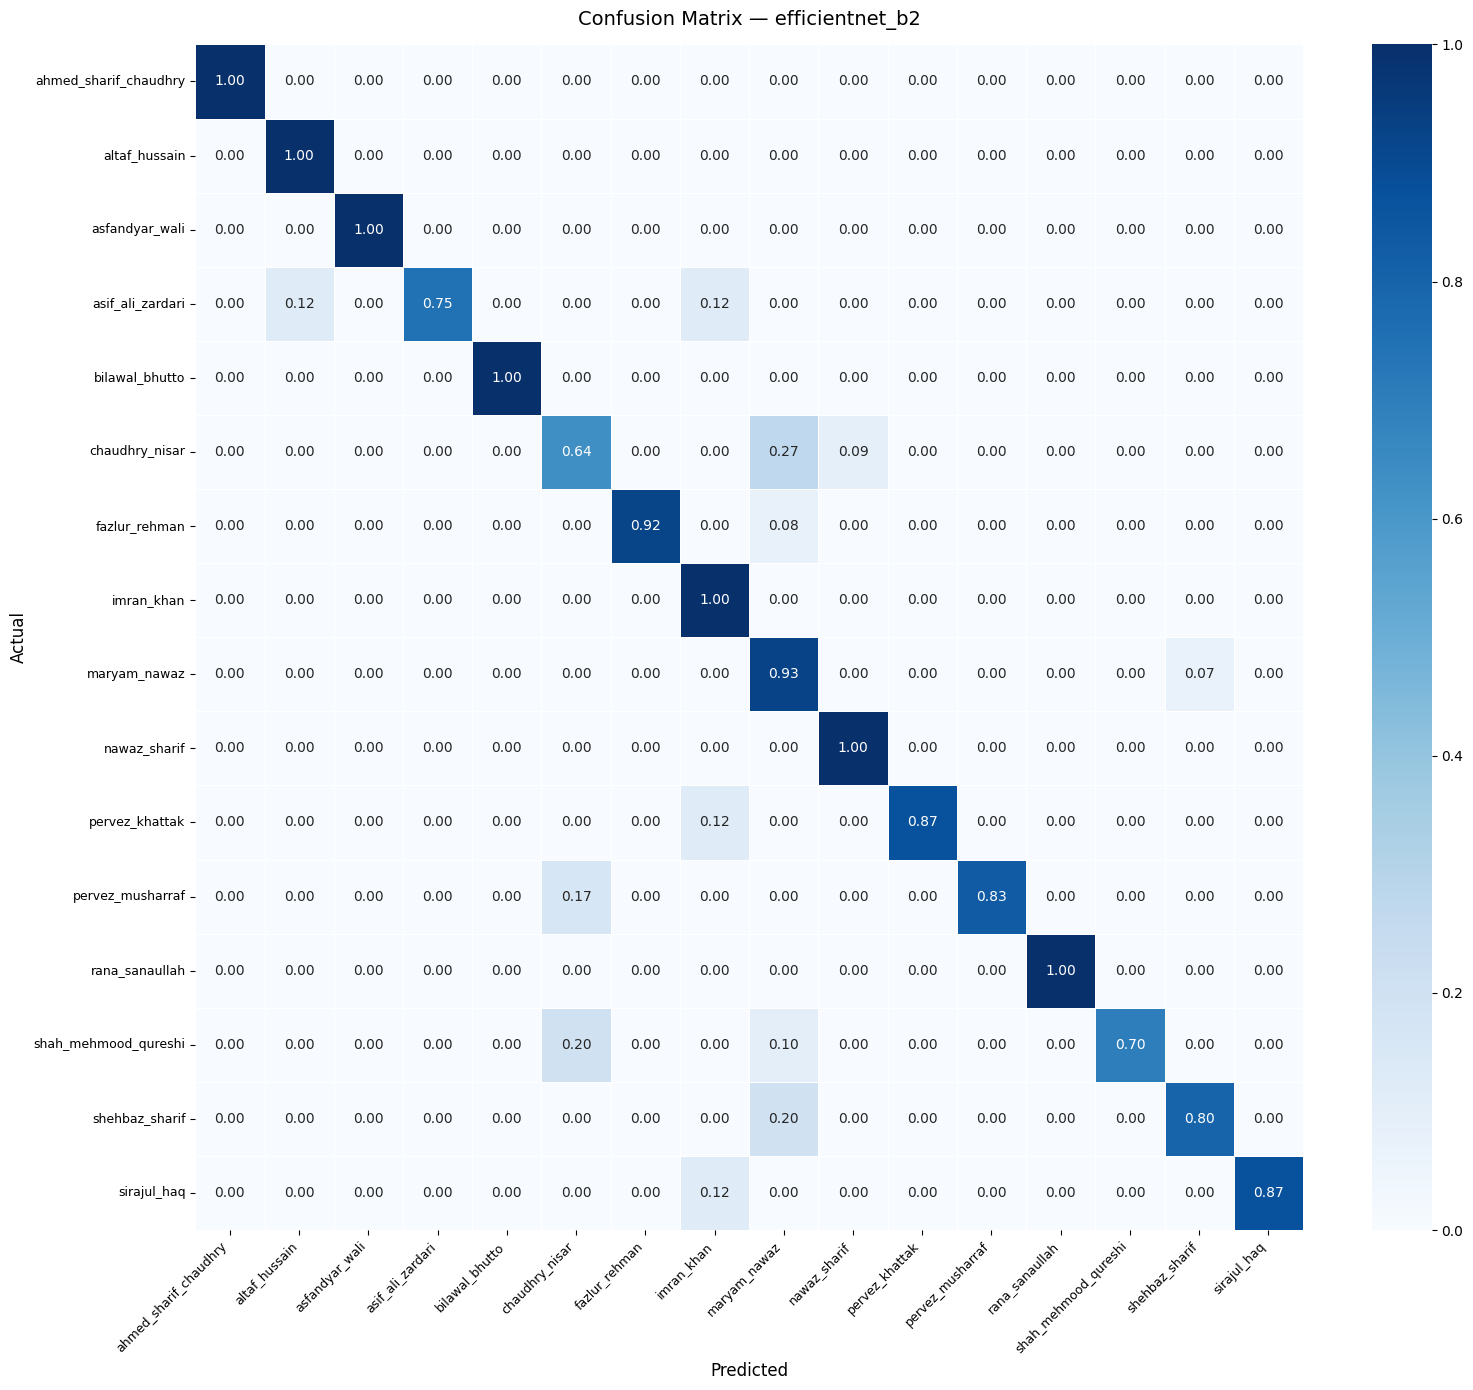

In [8]:
# ═══════════════════════════════════════════════
# (OPTIONAL) EfficientNet-B2  — uncomment to run
# ═══════════════════════════════════════════════

loaders_b2 = get_dataloaders(
    os.path.join(LOCAL_DATA_DIR, 'train'),
    os.path.join(LOCAL_DATA_DIR, 'val'),
    os.path.join(LOCAL_DATA_DIR, 'test'),
    image_size=260,   # B2 native resolution
)
model_b2 = build_model('efficientnet_b2', num_classes=16, dropout=0.4)
trainer_b2 = Trainer(model_b2, loaders_b2, 'efficientnet_b2',
                     config_overrides={'num_epochs': 30, 'learning_rate': 1e-4})
history_b2 = trainer_b2.run()
res_b2 = evaluate_model(model_b2, loaders_b2['test'], device, model_name='efficientnet_b2')
plot_confusion_matrix(res_b2['y_true'], res_b2['y_pred'], model_name='efficientnet_b2').show()

In [9]:
from src.utils import ExperimentLogger, save_results_to_drive
logger = ExperimentLogger()
logger.log(
    model_name    = 'efficientnet_b0',
    test_accuracy = round(res_b0['accuracy'], 4),
    macro_f1      = round(res_b0['report']['macro avg']['f1-score'], 4),
    epochs_run    = len(history_b0['train_loss']),
    lr=1e-4, batch_size=32,
    notes = 'Full fine-tuning, dropout=0.4',
)
save_results_to_drive('results', DRIVE_RESULTS)
print('✓ Done.  Next → 05_evaluation_and_plots.ipynb')

  Experiment logged → experiments/experiment_log.json
    model_name: efficientnet_b0
    test_accuracy: 0.8616
    macro_f1: 0.8654
    epochs_run: 30
    lr: 0.0001
    batch_size: 32
    notes: Full fine-tuning, dropout=0.4
    timestamp: 2026-05-13 19:15:44
  Saving results to Drive …
  Results saved → /content/drive/MyDrive/pk_politicians_results
✓ Done.  Next → 05_evaluation_and_plots.ipynb
